![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [3]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [4]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [6]:
# Celda 1
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Definición de la función que calcula la impureza para regresión (MSE)
def mse(y):
    if y.shape[0] == 0:
        return 0
    else:
        return np.mean((y - y.mean())**2)

# Definición de la función para calular la ganancia basada en reducción de MSE de una variable predictora j dado el punto de corte k
def mse_impurity(X_col, y, split):

    filter_l = X_col < split

    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]

    n_l = y_l.shape[0]
    n_r = y_r.shape[0]

    if n_l == 0 or n_r == 0:
        return 0

    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)

    gain = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)

    return gain

# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):

    features = range(X.shape[1])

    best_split = [0, 0, 0]  # j, split, gain

    # Para todas las varibles
    for j in features:

        col = X.iloc[:, j].astype(float)

        splits = np.percentile(col, np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]

        # Para cada partición
        for split in splits:
            gain = mse_impurity(col, y, split)

            if gain > best_split[2]:
                best_split = [j, split, gain]

    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):

    # Si solo hay una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[0], level=level, split=-1, n_samples=1, gain=0)
        return tree

    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)

    # Guardar el árbol y estimar la predicción
    y_pred = y.mean()

    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)

    # Revisar el criterio de parada
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree

    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]

    if X_l.shape[0] == 0 or X_r.shape[0] == 0:
        return tree

    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)

    return tree

# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'
def tree_predict(X, tree, proba=False):

    predicted = np.zeros(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        predicted[:] = tree['y_pred']

    else:

        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted

# Entrenar árbol
tree = tree_grow(X_train, y_train, max_depth=3)

# Predicción
y_pred = tree_predict(X_test, tree)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE Árbol Manual:", rmse)
print("MAE Árbol Manual:", mae)

RMSE Árbol Manual: 1921.0003286740268
MAE Árbol Manual: 1445.8091325887447


El árbol manual presenta una diferencia notable entre RMSE y MAE (RMSE > MAE), lo que sugiere la presencia de outliers o errores importantes en ciertas observaciones, ya que el RMSE penaliza más los errores grandes, mientras que el MAE trata todos los errores igual. Este modelo en promedio se equivoca 1445 dólares, pero tiene algunos casos donde se equivoca mucho más. Aunque el modelo captura patrones generales en los datos, su capacidad de generalización es limitada debido a la baja profundidad asignada (max_depth =3).

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [7]:
# Celda 2
# Creación de 10 muestras de bootstrap
np.random.seed(123)

n_samples = X_train.shape[0]
n_B = 10

samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_B)]

# Guardar las predicciones de cada árbol
y_pred = np.zeros((X_test.shape[0], n_B))

# Entrenamiento de un árbol sobre cada muestra boostrap y predicción sobre los datos de test
for i, sample in enumerate(samples):

    X_t_bag = X_train.iloc[sample]
    y_t_bag = y_train.iloc[sample]
    tree = tree_grow(X_t_bag, y_t_bag, max_depth=3)
    y_pred[:, i] = tree_predict(X_test, tree)

# Predicciones promedio para cada obserbación del set de test
y_pred_bagging = y_pred.mean(axis=1)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mae = mean_absolute_error(y_test, y_pred_bagging)

print("RMSE Bagging Manual:", rmse)
print("MAE Bagging Manual:", mae)

RMSE Bagging Manual: 1832.6459868667998
MAE Bagging Manual: 1376.3908840327795


El modelo de Bagging presenta una mejora en el desempeño respecto al árbol manual simple, lo cual se evidenciada en valores menores de RMSE y MAE. Esto se debe a que el Bagging disminuye la varianza del modelo. Sin embargo, la mejora no es significativa, ya que a los árboles utilizados tienen una profundidad limitada (max_depth=3), lo que introduce cierto sesgo en el modelo. Dado que el Bagging no reduce el sesgo, su capacidad de mejora se ve restringida.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [9]:
# Celda 3
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# Número de features
n_features = X_train.shape[1]

# Uso de BaggingRegressor --> modelo DecisionTreeRegressor como estimador
bagreg = BaggingRegressor(DecisionTreeRegressor(max_features=int(np.log(n_features))),
                          n_estimators=10, bootstrap=True,
                          oob_score=True, random_state=1)

# Entrenemiento del modelo con set de entrenamiento y predicción en el set de test
bagreg.fit(X_train, y_train)
y_pred = bagreg.predict(X_test)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE Bagging sklearn:", rmse)
print("MAE Bagging sklearn:", mae)

RMSE Bagging sklearn: 1824.292388455352
MAE Bagging sklearn: 1361.4820693001027


Bagging con sklearn presenta una mejora adicional en el desempeño respecto al Bagging manual, reduciendo el RMSE a 1824 y el MAE a 1361. Esto se debe a que la librería permite optimizar el entrenamiento y, adicionalmente, introducir aleatoriedad en la selección de variables mediante el parámetro max_features. Esto reduce la correlación entre los árboles del ensamble, aumentando la diversidad del modelo y mejorando su capacidad de generalización. Sin embargo, la mejora sigue siendo moderada debido a que el modelo continúa presentando sesgo asociado a la simplicidad de los árboles base.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [23]:
# Celda 4
from sklearn.ensemble import RandomForestRegressor

# Definición de modelo Random Forest para un problema de regresión
rf = RandomForestRegressor(n_estimators=100, random_state=1)

# Entrenamiento
rf.fit(X_train, y_train)

# Predicción
y_pred = rf.predict(X_test)

# Métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
mae_rf = mean_absolute_error(y_test, y_pred)

print("RMSE Random Forest:", rmse_rf)
print("MAE Random Forest:", mae_rf)

RMSE Random Forest: 1755.8727670097485
MAE Random Forest: 1307.0800496834686


El modelo de Random Forest sin calibración de hiperparámetros presenta un RMSE de 1755 y un MAE de 1307. Esta es uja mejora significativa en comparación con los modelos anteriores, ya que Random Forest combina el muestreo bootstrap del Bagging con la selección aleatoria de variables en cada división, reduciendo la correlación entre los árboles y aumentando la diversidad del modelo. De esta manera, se obtiene un modelo más robusto y con mejor capacidad de generalización a pesar de utilizar un número reducido de árboles (n_estimators=100)

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Mejor max_depth: 8



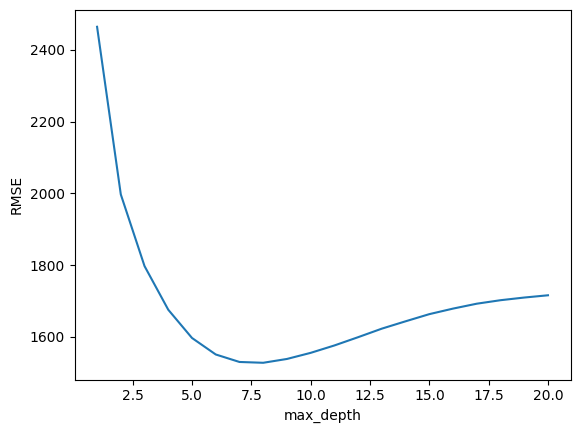

Mejor max_features: 4



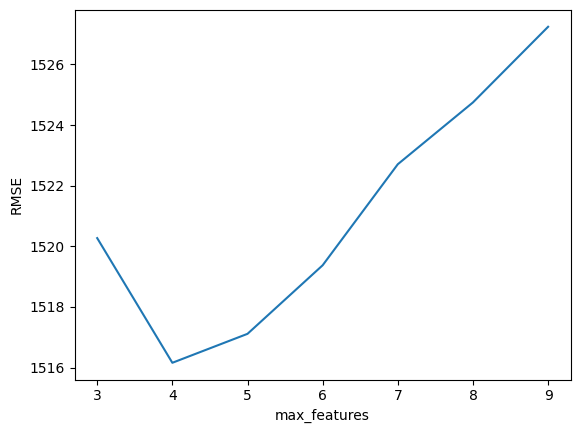

Mejor n_estimators: 280



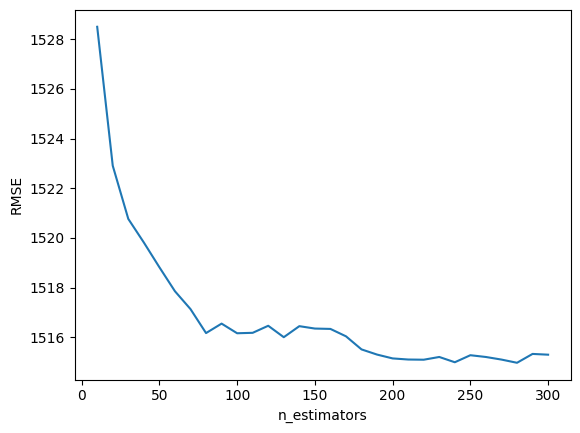

RMSE Random Forest Calibrado: 1552.1291620493587
MAE Random Forest Calibrado: 1138.5922723352235


In [24]:
# Celda 5
from sklearn.model_selection import cross_val_score

# MAX_DEPTH
# Creación de lista de valores para iterar sobre diferentes valores de max_features
depth_range = range(1, 21)

# Definición de lista para almacenar el rmse promedio para cada valor de max_depth
rmse_scores = []

# Uso de un 5-fold cross-validation para cada valor de max_depth
for depth in depth_range:
    rf = RandomForestRegressor(max_depth=depth, random_state=1, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores.append(-scores.mean())

# Mejor max_depth
best_depth = depth_range[np.argmin(rmse_scores)]
print("Mejor max_depth:", best_depth)
print()

# Gráfica del desempeño del modelo vs la cantidad de max_depth
plt.plot(depth_range, rmse_scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.show()

# MAX_FEATURES
# Creación de lista de valores para iterar sobre diferentes valores de max_features
feature_range = range(3, X_train.shape[1] + 1) #de p/3 a p por ser regresión

# Definición de lista para almacenar el rmse promedio para cada valor de max_features
rmse_scores = []

# Uso de un 5-fold cross-validation para cada valor de max_features
for feature in feature_range:
    rf = RandomForestRegressor(max_depth=best_depth, max_features=feature, random_state=1, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores.append(-scores.mean())

# Mejor max_feautures
best_features = feature_range[np.argmin(rmse_scores)]
print("Mejor max_features:", best_features)
print()

# Gráfica del desempeño del modelo vs la cantidad de max_features
plt.plot(feature_range, rmse_scores)
plt.xlabel('max_features')
plt.ylabel('RMSE')
plt.show()

# N_ESTIMATORS
# Creación de lista de valores para iterar sobre diferentes valores de n_estimators
estimator_range = range(10, 310, 10)

# Definición de lista para almacenar el rmse promedio para cada valor de n_estimators
rmse_scores = []

# Uso de un 5-fold cross-validation para cada valor de n_estimators
for estimator in estimator_range:
    rf = RandomForestRegressor(max_depth=best_depth, max_features=best_features, n_estimators=estimator, random_state=1, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores.append(-scores.mean())

# Mejor n_stimators
best_estimators = estimator_range[np.argmin(rmse_scores)]
print("Mejor n_estimators:", best_estimators)
print()

# Gráfica del desempeño del modelo vs la cantidad de n_estimators
plt.plot(estimator_range, rmse_scores)
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.show()

# IMPLEMENTACIÓN CON LOS MEJORES PARÁMETROS
# Definición del modelo con los mejores parámetros
rfc = RandomForestRegressor(max_depth=best_depth,
                            max_features=best_features,
                            n_estimators=best_estimators,
                            random_state=1,
                            n_jobs=-1)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

# Métricas
rmse_rfc = np.sqrt(mean_squared_error(y_test, y_pred))
mae_rfc = mean_absolute_error(y_test, y_pred)

print("RMSE Random Forest Calibrado:", rmse_rfc)
print("MAE Random Forest Calibrado:", mae_rfc)

La selección de hiperparámetros se realizó minimizando el RMSE promedio obtenido mediante validación cruzada, permitiendo identificar los valores óptimos de cada parámetro con tuning acumulativo.

La calibración permitió mejorar significativamente el desempeño del modelo Random Forest, reduciendo el RMSE a 1552 y el MAE a 1138. Se encontró que un valor de max_depth=8 proporciona un buen equilibrio entre complejidad y generalización, evitando el sobreajuste. El parámetro max_features=4 permitió reducir la correlación entre los árboles, aumentando la diversidad del modelo. Por su parte, un valor alto de n_estimators=280 contribuyó a reducir la varianza del modelo, generando predicciones más estables (menor desempeño al aumentar el número de árboles). En conjunto, estos ajustes permiten obtener un modelo más robusto y con mejor capacidad predictiva frente al mismo modelo sin calibración de parámetros.  

El parámetro max_depth controla la profundidad de los árboles: valores pocos profundos generan modelos simples con alto sesgo, mientras que valores altos permiten capturar relaciones más complejas, aunque pueden llevar al sobreajuste. El parámetro max_features determina el número de variables consideradas en cada división, donde valores menores reducen la correlación entre los árboles y mejoran la generalización del modelo, ya que si el valor es igual al número total de variables se pierde poder predictivo. Finalmente, n_estimators define el número de árboles en el ensamble, donde un mayor número de árboles reduce la varianza y mejora la estabilidad del modelo, permitiendo un mejor desempeño del modelo.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [25]:
# Celda 6
# Importación y definición de modelo XGBClassifier
from xgboost import XGBRegressor

xgb = XGBRegressor(learning_rate=0.1, random_state=1)

# Entrenamiento (fit) del modelo XGBRegressor
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

# Métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mae_xgb = mean_absolute_error(y_test, y_pred)

print("RMSE XGBoost:", rmse_xgb)
print("MAE XGBoost:", mae_xgb)

RMSE XGBoost: 1563.297956245066
MAE XGBoost: 1146.633544921875


El modelo XGBoost presenta un desempeño aceptable en comparación con otros modelos evaluados, logrando un RMSE de 1563 y un MAE de 1146. Sin embargo, no muestra una mejora respecto al modelo Random Forest con hyperparameter tuning es poca. Esto se debe a que, aunque XGBoost funciona de manera secuencial corrigiendo los errores del árbol anterior y reduciendo tanto el sesgo como la varianza, su desempeño depende en gran medida de la calibración de sus hiperparámetros.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Mejor learning_rate: 0.040999999999999995



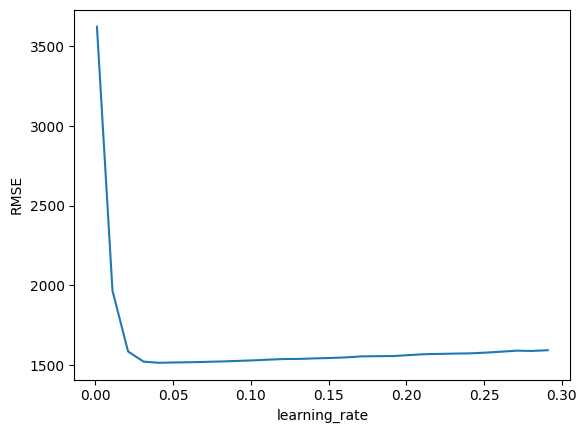

Mejor gamma: 0



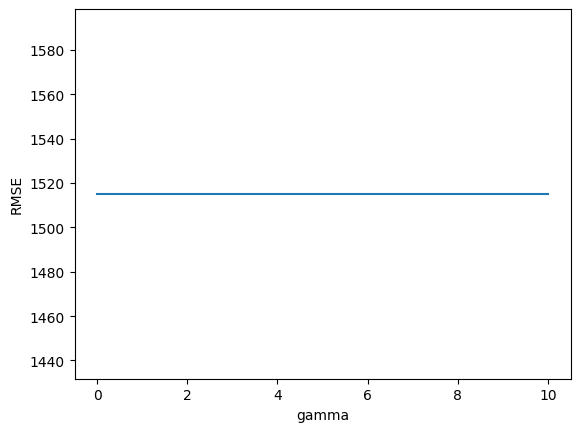

Mejor colsample_bytree: 0.8000000000000003



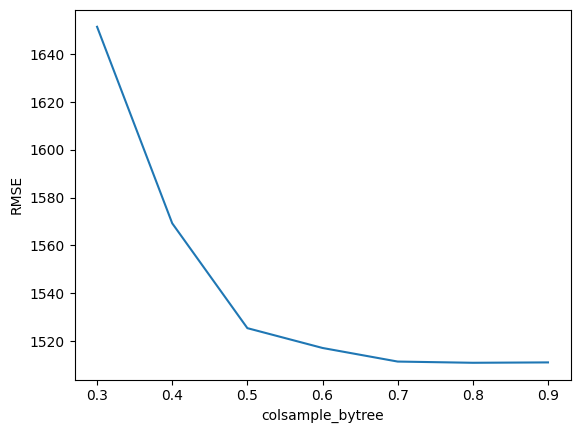

RMSE XGBoost: 1547.7782463906126
MAE XGBoost: 1136.56591796875


In [26]:
# Celda 7

# LEARNING RATE
# Creación de lista de valores para iterar sobre diferentes learning_rate
lr_range = np.arange(0.001, 0.301, 0.01)

# Definición de lista para almacenar el rmse promedio para cada valor de learning_rate
rmse_scores = []

# Uso de un 5-fold cross-validation para cada valor de learning_rate
for lr in lr_range:
    xgb = XGBRegressor(learning_rate=lr, random_state=1, n_jobs=-1)
    scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores.append(-scores.mean())

# Mejor learning_rate
best_lr = lr_range[np.argmin(rmse_scores)]
print("Mejor learning_rate:", best_lr)
print()

# Gráfica del desempeño del modelo vs el learning_rate
plt.plot(lr_range, rmse_scores)
plt.xlabel('learning_rate')
plt.ylabel('RMSE')
plt.show()

# GAMMA
# Creación de lista de valores para iterar sobre diferentes valores de gamma
gamma_range = range(0, 11)

# Definición de lista para almacenar el rmse promedio para cada valor de gamma
rmse_scores = []

# Uso de un 5-fold cross-validation para cada valor de gamma
for g in gamma_range:
    xgb = XGBRegressor(learning_rate=best_lr, gamma=g, random_state=1, n_jobs=-1)
    scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores.append(-scores.mean())

# Mejor gamma
best_gamma = gamma_range[np.argmin(rmse_scores)]
print("Mejor gamma:", best_gamma)
print()

# Gráfica del desempeño del modelo vs gamma
plt.plot(gamma_range, rmse_scores)
plt.xlabel('gamma')
plt.ylabel('RMSE')
plt.show()

# COLSAMPLE BYTREE
# Creación de lista de valores para iterar sobre diferentes valores de colsample_bytree
colsample_range = np.arange(0.3, 0.9, 0.1)

# Definición de lista para almacenar el rmse promedio para cada valor de colsample_bytree
rmse_scores = []

# Uso de un 5-fold cross-validation para cada valor de colsample_bytree
for colsample in colsample_range:
    xgb = XGBRegressor(learning_rate=best_lr, gamma=best_gamma, colsample_bytree=colsample, random_state=1, n_jobs=-1)
    scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores.append(-scores.mean())

# Mejor colsample_bytree
best_col = colsample_range[np.argmin(rmse_scores)]
print("Mejor colsample_bytree:", best_col)
print()

# Gráfica del desempeño del modelo vs colsample_bytree
plt.plot(colsample_range, rmse_scores)
plt.xlabel('colsample_bytree')
plt.ylabel('RMSE')
plt.show()

# IMPLEMENTACIÓN CON LOS MEJORES PARÁMETROS
# Definición del modelo con los mejores parámetros encontrados
xgbc = XGBRegressor(learning_rate=best_lr,
                    gamma=best_gamma,
                    colsample_bytree=best_col,
                    n_estimators=150,
                    random_state=1,
                    n_jobs=-1)

xgbc.fit(X_train, y_train)
y_pred = xgbc.predict(X_test)

# Métricas
rmse_xgbc = np.sqrt(mean_squared_error(y_test, y_pred))
mae_xgbc = mean_absolute_error(y_test, y_pred)

print("RMSE XGBoost:", rmse_xgbc)
print("MAE XGBoost:", mae_xgbc)

XGBoost es altamente sensible a la interacción entre hiperparámetros, a diferencia de Random Forest

El modelo XGBoost calibrado presenta un buen desempeño, con un RMSE de 1547 y un MAE de 1136, lo que indica que el error promedio en la predicción del precio de los vehículos es relativamente bajo. La cercanía entre ambas métricas sugiere que el modelo no presenta errores extremadamente grandes de forma frecuente, lo que refleja estabilidad en las predicciones.

La calibración de hiperparámetros con tuning acumulativo permitió analizar el impacto de cada parámetro en el desempeño del modelo. El parámetro learning_rate controla la contribución de cada árbol al modelo final, donde valores bajos generan un aprendizaje más lento pero robusto, mientras que valores altos pueden inducir sobreajuste. El parámetro gamma regula la complejidad del modelo, penalizando divisiones innecesarias y ayudando a controlar el sobreajuste (Un valor de 0 indica que no se penalizan las divisiones, permitiendo que el modelo capture patrones más complejos en los datos). Por su parte, colsample_bytree define la proporción de variables utilizadas en cada árbol, lo que influye en la diversidad del modelo.

En conjunto, la calibración de estos parámetros permite mejorar el desempeño del modelo al encontrar un balance adecuado entre sesgo y varianza.

La calibración de hiperparámetros en XGBoost permitió optimizar el desempeño del modelo mediante el ajuste de parámetros clave. El parámetro learning_rate controla la velocidad de aprendizaje del modelo, donde valores bajos permiten un aprendizaje más gradual y mejor generalización, mientras que valores altos pueden generar sobreajuste. El parámetro gamma regula la complejidad del árbol al definir el mínimo incremento en la función de pérdida requerido para realizar una partición, actuando como un mecanismo de regularización que evita divisiones innecesarias. Por su parte, colsample_bytree controla la proporción de variables utilizadas en cada árbol, reduciendo la correlación entre modelos y mejorando la generalización. En conjunto, la calibración de estos parámetros permite mejorar el balance entre sesgo y varianza, logrando un modelo más robusto y con mejor desempeño predictivo.





La selección de hiperparámetros se realizó minimizando el RMSE promedio obtenido mediante validación cruzada, permitiendo identificar los valores óptimos de cada parámetro mediante un proceso de tuning acumulativo.

La calibración permitió mejorar el desempeño del modelo XGBoost, reduciendo el RMSE a 1547 y el MAE a 1136. Se encontró que un valor de learning_rate=0.041 permite un aprendizaje más gradual, evitando el sobreajuste y mejorando la capacidad de generalización del modelo. El parámetro gamma=0 indica que no es necesario penalizar la creación de nuevas particiones, permitiendo al modelo capturar relaciones más complejas en los datos. Por su parte, un valor de colsample_bytree=0.8 introduce aleatoriedad en la selección de variables, reduciendo la correlación entre los árboles y mejorando la robustez del modelo. En conjunto, estos ajustes permiten obtener un modelo más preciso y estable frente al modelo sin calibración.

El parámetro learning_rate controla la contribución de cada árbol en el modelo, donde valores bajos generan un aprendizaje más lento pero mejor generalización, mientras que valores altos pueden acelerar el aprendizaje a costa de mayor riesgo de sobreajuste. El parámetro gamma regula la complejidad del modelo al penalizar nuevas divisiones, donde valores altos restringen el crecimiento del árbol y reducen el sobreajuste, mientras que valores bajos permiten capturar patrones más complejos. Finalmente, colsample_bytree determina la proporción de variables utilizadas en cada árbol, donde valores menores reducen la correlación entre los árboles y mejoran la generalización, mientras que valores altos incrementan la capacidad predictiva individual de cada árbol pero pueden aumentar la correlación del modelo.

### Punto 8 - Comparación y análisis de resultados

En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.



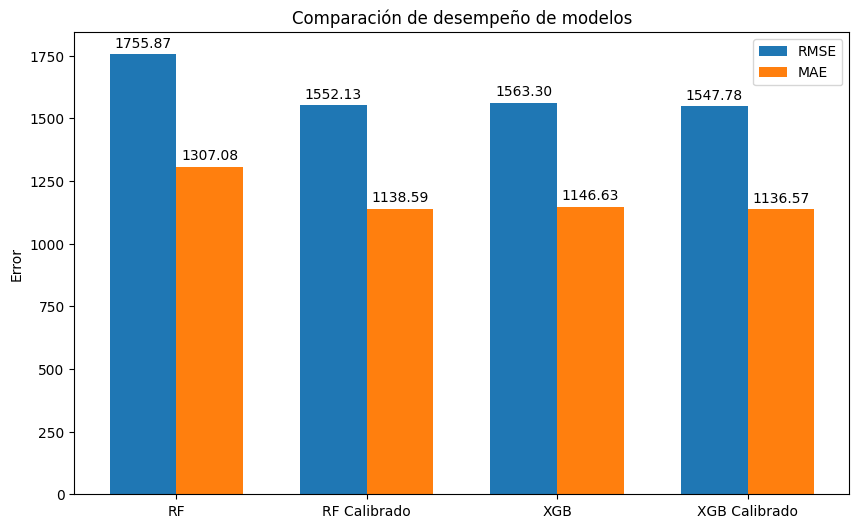

In [35]:
# Celda 8
models = ['RF', 'RF Calibrado', 'XGB', 'XGB Calibrado']

rmse = [rmse_rf, rmse_rfc, rmse_xgb, rmse_xgbc]
mae = [mae_rf, mae_rfc, mae_xgb, mae_xgbc]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
bar1 = plt.bar(x - width/2, rmse, width, label='RMSE')
bar2 = plt.bar(x + width/2, mae, width, label='MAE')

plt.bar_label(bar1, padding=3, fmt='%.2f')
plt.bar_label(bar2, padding=3, fmt='%.2f')

plt.xticks(x, models)
plt.ylabel('Error')
plt.title('Comparación de desempeño de modelos')
plt.legend()

plt.show()